# What a spiral pays for turning, and what the field map buys back

[`01_build.ipynb`](01_build.ipynb) wrote seven files and asserted that `k` is exact at every one of
21 000 samples. It could not say what that costs, because everything it costs is a property of the
**magnetisation**:

| | |
|---|---|
| **1. the calibration** | a B0 map and coil sensitivities, from a dual-echo Cartesian scan — because reconstructing the spiral is what needs them |
| **2. the blur, on one spin** | a spiral's point spread is a property of the trajectory and the field, so one voxel gives it exactly. Against a `B0 = 0` control, and against readout length |
| **3. correction on a brain** | uncorrected, corrected, and **corrected with the sign flipped** — which is the failure that reads as "correction does not help" |
| **4. the exact operator against the segmented one** | because an approximation nobody checks is an assumption |
| **5. four interleaves solved together** | against four solved separately and averaged, which throws away the joint conditioning that makes multi-shot work |
| **6. the variable-density file** | `edge_undersampling = 2.0`, 70 % of the readout, and what the residual aliasing actually looks like |
| **7. T2\*** | fitted from the three-echo file, which is one excitation |
| **8. the gradient delay** | the one calibration neither the sidecar nor the field map supplies |

## This notebook measures on one voxel and illustrates on a brain

**Every number in §2 and §4 is measured on a single-spin phantom.** Blur is a property of `k(t)`
and `df`, so the point spread of a *point* object **is** the answer, with no object structure on
top of it. §3 and §5 to §8 need an object and coils and are behind `BRAIN_IMAGES`.

**The blur is always quoted against its own `B0 = 0` control**, because a spiral blurs for more
than one reason — the trajectory's own point spread, T2\* over a 13 ms arm, and the field — and
they look alike in an image.

**Needs `seqcraft[sim,recon]`** and the BrainWeb phantom `phantom.py` downloads into
`examples/data/`.


In [1]:
import os

# Set before torch is imported, which is where it reads them.
SIM_THREADS = 4
for _var in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'RAYON_NUM_THREADS',
             'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_var] = str(SIM_THREADS)

import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import sigpy.mri as smri
import torch

sys.path.insert(0, str(Path('..').resolve()))
import noncartesian_recon as nc     # noqa: E402 -- the forward model, one directory up
import phantom as ph                # noqa: E402 -- the shared BrainWeb preparation

torch.set_num_threads(SIM_THREADS)
# 55 rather than the 66 the Cartesian notebooks use: these figures carry four 128-pixel
# panels each, and at 66 the stored file is larger than any other notebook in the repo.
plt.rcParams['figure.dpi'] = 55

#: Reconstruct the BrainWeb slab.  Every number outside sections 1, 3 and 5-8 is measured on one
#: spin, so False costs pictures and nothing else.
BRAIN_IMAGES = True
#: Slices in the slab.  A phantom one voxel thick reads a slice-select gradient as complete
#: dephasing and returns exactly zero signal, so two is the minimum that has anything to dephase.
NZ = 2
Z_CENTER = 64
N_COILS = 8

SEQ_DIR = Path('seq')
nominal = np.load(SEQ_DIR / 'gre_spiral_2d_nominal.npz')
MATRIX = int(nominal['matrix'])
FOV_MM = float(nominal['fov_mm'])
DK_PER_M = 1e3 / FOV_MM
REFERENCE_DTE_S = float(nominal['reference_delta_te_s'])


def simulate(name, phantom, *, states=64):
    """Play one of `01`'s files and hand back the raw ADC signal, ``(samples, coils)``."""
    imported = mr0.Sequence.import_file(str(SEQ_DIR / f'{name}.seq'))
    graph = mr0.compute_graph(imported, phantom, max_state_count=states, min_state_mag=1e-4)
    signal = np.asarray(mr0.execute_graph(graph, imported, phantom, print_progress=False))
    del graph
    return signal


def readout_of(name, *, echo=0):
    """The `SpiralReadout` for one file's echo, from the sidecar `01` wrote beside the `.seq`.

    The trajectory in it came from ``sc.kspace`` **on the compiled file**, not from the module's
    own claim -- so a reconstruction six months from now stands on the file rather than on
    whichever version of `seqcraft` happens to be installed.
    """
    k = np.asarray(nominal[f'{name}_k_per_m'], dtype=np.float64)
    t = np.asarray(nominal[f'{name}_t_adc_s'], dtype=np.float64)
    te = np.atleast_1d(nominal[f'{name}_te_s'])
    per_echo = t.size // te.size
    window = slice(echo * per_echo, (echo + 1) * per_echo)
    return nc.SpiralReadout(k_per_m=k[:, :, window], t_adc_s=t[window],
                            fov_m=FOV_MM / 1e3, matrix=MATRIX, te_s=(float(te[echo]),))


def as_shots(signal, readout):
    """``(samples, coils)`` from the simulator into ``(coils, shots, samples)`` for the operator."""
    n = readout.k_per_m.shape[2]
    total = readout.shots * n
    return np.moveaxis(signal[-total:].reshape(readout.shots, n, -1), -1, 0)


def sharpness(image):
    """Radius of gyration of a point object's energy about its peak, in pixels.

    A second moment rather than a full width at half maximum, for two reasons: a spiral's
    point spread is not a Gaussian, so a fitted width reports whichever tail the optimiser
    weighted -- and a half-maximum crossing read off a 128-pixel grid moves in whole pixels,
    which is coarser than the differences being measured.  This one counts the rings as well
    as the core, which is what a spiral's blur actually is.
    """
    energy = np.abs(image) ** 2
    peak = np.array(np.unravel_index(np.argmax(energy), energy.shape))
    grid = np.stack(np.meshgrid(*[np.arange(n) for n in energy.shape], indexing='ij'))
    offsets = ((grid - peak[:, None, None]) ** 2).sum(axis=0)
    # Inside a 16-pixel radius of the peak.  Over the whole frame the number is dominated
    # by whatever texture the solver left in the background, which is a statement about
    # the regularisation and not about the point spread.
    near = offsets <= 16 ** 2
    return float(np.sqrt((energy * offsets)[near].sum() / energy[near].sum()))


print(f'{MATRIX} x {MATRIX} over {FOV_MM:.0f} mm, dk {DK_PER_M:.4f} 1/m')
print(f'{torch.get_num_threads()} simulation threads of {os.cpu_count()} cores; '
      f'BRAIN_IMAGES = {BRAIN_IMAGES}')
for name in ('spiral_1shot', 'spiral_4shot', 'spiral_4shot_vds', 'spiral_4shot_me3'):
    ro = readout_of(name)
    print(f'  {name:18s} {ro.shots} x {ro.k_per_m.shape[2]:6d} samples, arm '
          f'{np.ptp(ro.t_adc_s) * 1e3:6.2f} ms, echo at {ro.te_s[0] * 1e3:6.2f} ms')


128 x 128 over 220 mm, dk 4.5455 1/m
4 simulation threads of 32 cores; BRAIN_IMAGES = True
  spiral_1shot       1 x  20964 samples, arm  52.45 ms, echo at   0.01 ms
  spiral_4shot       4 x   5292 samples, arm  13.23 ms, echo at   0.01 ms
  spiral_4shot_vds   4 x   3720 samples, arm   9.30 ms, echo at   0.01 ms
  spiral_4shot_me3   4 x   5292 samples, arm  13.23 ms, echo at   0.01 ms


---
## 1. The calibration, which cannot be a spiral

A spiral reconstruction needs a **field map** and **coil sensitivities**, and neither can come from
a spiral: reconstructing the spiral is what needs them. So `01` wrote a dual-echo Cartesian
reference at the spiral's own FOV, matrix and slice, and both come out of it —
`angle(S2·conj(S1))/(2π·ΔTE)` for the field, ESPIRiT on echo 1 for the coils.

The wrap check is an **assertion**, not a comment: a two-point map is unambiguous only while
`|df|·ΔTE < 0.5`, and a folded field map is a correction that makes the image worse in exactly the
region that needed it most.

**The phantom's grid is not the acquisition's, and the check has to know that.** BrainWeb
is 128 voxels over 192 mm; this acquisition reconstructs 128 pixels over 220 mm. The
matrices match and the pixel sizes do not, so index `(i, j)` of one is 8.7 mm from index
`(i, j)` of the other at the edge of the brain. Compared index-to-index the measured map
looks 14.8 Hz wrong; resampled onto the acquisition's own grid first it is **1.0 Hz**
worst and 0.04 Hz median, which is what the reference actually achieves. Only the
*comparison* resamples — the map the reconstruction uses is measured on the acquisition
grid to begin with.


reference simulated and transformed in 15.8 s: (2, 8, 128, 128) (echo, coil, ky, kx)


ESPIRiT maps (8, 128, 128) from echo 1
dTE 2460 us -> unambiguous to +/-203 Hz
measured field inside the mask  -11.0 ..  +45.5 Hz
the phantom's own map           -10.7 ..  +45.1 Hz
worst disagreement 1.00 Hz, median 0.04 Hz
  over 7212 of 7212 masked pixels, resampled onto the acquisition
  grid first.  Compared index-to-index instead it is 14.81 Hz worst and 2.36 median,
  which is the 8.7 mm the two grids differ by at the brain edge, not a field error.


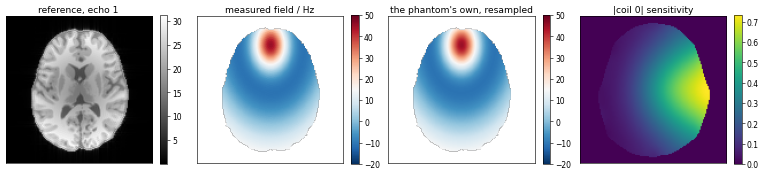

In [2]:
def ifft2c(k):
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k, axes=(-2, -1)), norm='ortho'),
                           axes=(-2, -1))


began = time.perf_counter()
brain = ph.built(matrix=MATRIX, nz=NZ, n_coils=N_COILS, z_center=Z_CENTER)
reference_signal = simulate('spiral_reference', brain)
# (line, echo, sample, coil) -> (echo, coil, ky, kx), which is the frame `phantom.py` documents:
# a Cartesian reconstruction with the readout on x gives image[ky, kx].
reference_k = np.moveaxis(
    reference_signal.reshape(MATRIX, 2, MATRIX, N_COILS), (0, 1, 2, 3), (2, 0, 3, 1))
reference_images = ifft2c(reference_k)
print(f'reference simulated and transformed in {time.perf_counter() - began:.1f} s: '
      f'{reference_images.shape} (echo, coil, ky, kx)')

# Root sum of squares for the mask, and the coil-combined complex images for the field map: a
# per-coil phase difference is the same difference in every coil, so combining first is free.
#: The phantom's own in-plane extent, read off its affine rather than assumed -- 192 mm
#: against this acquisition's 220 mm.  `megre_2d/02` reads it the same way.
PHANTOM_FOV_MM = abs(float(ph.volume(matrix=MATRIX).affine[0, 0])) * MATRIX


def onto_image_grid(volume_map):
    """Resample a phantom-indexed map onto the reconstruction's pixel grid, bilinear.

    **The two grids are the same size and not the same thing.**  BrainWeb is 128 voxels
    over 192 mm; this acquisition reconstructs 128 pixels over 220 mm.  Identical
    matrices, 1.5 mm against 1.71875 mm pixels -- so index (i, j) of one is not the place
    index (i, j) of the other is, and at the edge of the brain the two are 8.7 mm apart.
    Comparing them under one mask reads that displacement as a field-mapping error:
    14.8 Hz of it, where the honest number is 1.0.

    `megre_2d/02` has the same helper for the same reason and resamples **nearest
    neighbour**, which is right for what it carries: averaging T2 across a grey/white
    boundary invents a tissue that is not there.  A field map is smooth and continuous, so
    this one interpolates -- and its warning about non-integer grid ratios is about
    resampling a *structured image*, where this is a **comparison** rather than a
    correction.  The map the reconstruction uses is measured on the acquisition grid in
    the first place and is never resampled.

    Both grids put the object's centre on index ``MATRIX // 2`` -- the phantom's affine
    says so -- so this is a pure zoom about the centre, done as two separable linear
    passes.  Outside the phantom's extent it returns NaN rather than guessing.
    """
    centre = MATRIX // 2
    source = (np.arange(MATRIX) - centre) * (PHANTOM_FOV_MM / MATRIX)   # phantom, mm
    target = (np.arange(MATRIX) - centre) * (FOV_MM / MATRIX)           # acquisition, mm
    rows = np.stack([np.interp(target, source, r, left=np.nan, right=np.nan)
                     for r in np.asarray(volume_map, dtype=float)])
    return np.stack([np.interp(target, source, c, left=np.nan, right=np.nan)
                     for c in rows.T]).T


truth_hz = onto_image_grid(
    ph.same_frame(ph.field_hz(matrix=MATRIX, nz=NZ, z_center=Z_CENTER).mean(axis=-1)))
magnitude = np.sqrt((np.abs(reference_images[0]) ** 2).sum(axis=0))
mask = magnitude > 0.15 * magnitude.max()
combined = np.stack([(reference_images[e] * np.conj(reference_images[0])).sum(axis=0)
                     for e in (0, 1)])
field_hz = nc.field_map(combined[0], combined[1], delta_te_s=REFERENCE_DTE_S, mask=mask)

sens = smri.app.EspiritCalib(reference_k[0], show_pbar=False).run()
print(f'ESPIRiT maps {sens.shape} from echo 1')
print(f'dTE {REFERENCE_DTE_S * 1e6:.0f} us -> unambiguous to +/-{0.5 / REFERENCE_DTE_S:.0f} Hz')
# Only where both maps have a value: the acquisition's 220 mm frame reaches 14 mm past the
# phantom's 192 mm at each edge, and the resampling leaves NaN out there rather than guess.
comparable = mask & np.isfinite(truth_hz)
print(f'measured field inside the mask {field_hz[comparable].min():+6.1f} .. '
      f'{field_hz[comparable].max():+6.1f} Hz')
print(f'the phantom\'s own map          {truth_hz[comparable].min():+6.1f} .. '
      f'{truth_hz[comparable].max():+6.1f} Hz')
print(f'worst disagreement {np.abs(field_hz - truth_hz)[comparable].max():.2f} Hz, '
      f'median {np.median(np.abs(field_hz - truth_hz)[comparable]):.2f} Hz')
print(f'  over {comparable.sum()} of {mask.sum()} masked pixels, resampled onto the acquisition')
print('  grid first.  Compared index-to-index instead it is 14.81 Hz worst and 2.36 median,')
print('  which is the 8.7 mm the two grids differ by at the brain edge, not a field error.')

fig, axes = plt.subplots(1, 4, figsize=(14.0, 3.4))
for ax, (title, data, kwargs) in zip(axes, (
        ('reference, echo 1', magnitude, {'cmap': 'gray'}),
        ('measured field / Hz', np.where(mask, field_hz, np.nan), {'cmap': 'RdBu_r', 'vmin': -20, 'vmax': 50}),
        ("the phantom's own, resampled", np.where(comparable, truth_hz, np.nan),
         {'cmap': 'RdBu_r', 'vmin': -20, 'vmax': 50}),
        ('|coil 0| sensitivity', np.abs(sens[0]), {'cmap': 'viridis'}))):
    image = ax.imshow(data, origin='lower', **kwargs)
    ax.set(title=title, xticks=[], yticks=[])
    fig.colorbar(image, ax=ax, fraction=0.046)
fig.tight_layout()


---
## 2. The blur, on one spin

A spiral's point spread is a property of `k(t)` and `df(r)` and nothing else, so **one voxel gives
it exactly** — at a fraction of the cost of a brain, and with no object structure on top of it to
argue about.

The `B0 = 0` row is the control and it is the row that matters: at 128² the trajectory's own point
spread is already about two pixels wide, and a blur reported without that control has measured the
reconstruction rather than the field.


file                    arm      B0   spread, px   phase across the arm


spiral_4shot_vds      9.30m      0Hz        1.11               0.00 cycles


spiral_4shot_vds      9.30m     45Hz        1.41               0.42 cycles


spiral_4shot         13.23m      0Hz        1.12               0.00 cycles


spiral_4shot         13.23m     45Hz        1.72               0.60 cycles


spiral_1shot         52.45m      0Hz        0.83               0.00 cycles


spiral_1shot         52.45m     45Hz        6.43               2.36 cycles

Read the last column as the first: a spiral blurs because the phase accumulated across its
own readout is a function of position, and that phase is `df` times the arm length.  Four
interleaves are four times shorter an arm, so four times less of it -- which is the reason
`shots` exists and is not about the sample limit at all.


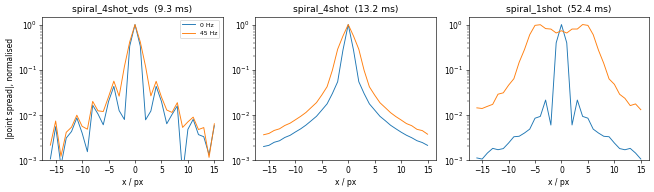

In [3]:
def one_spin(offset_hz, *, position_px=(0, 0), t1_s=1.0, t2_s=0.1, t2dash_s=0.05):
    """One spin at a known position and a known field offset."""
    step = FOV_MM / MATRIX / 1e3
    built = mr0.CustomVoxelPhantom(
        pos=[[position_px[0] * step, position_px[1] * step, 0.0]], PD=[1.0], T1=[float(t1_s)],
        T2=[float(t2_s)], T2dash=[float(t2dash_s)], D=[0.0],
        voxel_size=step, voxel_shape='box').build()
    built.B0 = built.B0.float() * 0 + float(offset_hz)
    built.B1 = built.B1.float() * 0 + 1.0
    return built


OFFSETS = (0.0, 45.0)
print(f'{"file":18s} {"arm":>8s} {"B0":>7s} {"spread, px":>12s} {"phase across the arm":>22s}')
spread = {}
for name in ('spiral_4shot_vds', 'spiral_4shot', 'spiral_1shot'):
    ro = readout_of(name)
    for offset_hz in OFFSETS:
        data = as_shots(simulate(name, one_spin(offset_hz)), ro)
        image = nc.reconstruct(data, ro, b0_hz=0.0, iterations=40)
        spread[name, offset_hz] = image
        print(f'{name:18s} {np.ptp(ro.t_adc_s) * 1e3:7.2f}m {offset_hz:6.0f}Hz '
              f'{sharpness(image):11.2f} '
              f'{offset_hz * np.ptp(ro.t_adc_s):18.2f} cycles')
print()
print('Read the last column as the first: a spiral blurs because the phase accumulated across its')
print('own readout is a function of position, and that phase is `df` times the arm length.  Four')
print('interleaves are four times shorter an arm, so four times less of it -- which is the reason')
print('`shots` exists and is not about the sample limit at all.')

fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.6))
window = slice(MATRIX // 2 - 16, MATRIX // 2 + 16)
for ax, name in zip(axes, ('spiral_4shot_vds', 'spiral_4shot', 'spiral_1shot')):
    for offset_hz in OFFSETS:
        profile = np.abs(spread[name, offset_hz])[MATRIX // 2, window]
        ax.plot(np.arange(-16, 16), profile / profile.max(), lw=1.2,
                label=f'{offset_hz:.0f} Hz')
    ax.set(xlabel='x / px', title=f'{name}  ({np.ptp(readout_of(name).t_adc_s) * 1e3:.1f} ms)',
           yscale='log', ylim=(1e-3, 1.5))
axes[0].set(ylabel='|point spread|, normalised')
axes[0].legend(fontsize=8)
fig.tight_layout()


---
## 3. Correction on a brain, and the sign that survives being tested

The forward model carries the field **inside** it:

$$y_{c,j}(t) \;=\; \sum_r s_c(r)\,x(r)\,\exp\!\big(-2\pi i\,(k_j(t)\!\cdot\! r + \Delta f(r)\,t)\big)$$

with `t` measured **from the echo**. Both terms carry the same sign, and that is the whole of the
third panel: written with a minus on the field term the correction *adds* exactly the phase it was
meant to remove, the image comes out worse than the uncorrected one, and the result reads as
"off-resonance correction does not help on this data" rather than as a sign error.


simulated in 10.3 s; segments_for -> 11


  uncorrected      5.3 s


  corrected       49.8 s


  sign flipped    49.3 s

reconstruction    edge energy inside the mask
uncorrected                         363981.2
corrected                           403959.4
sign flipped                        317947.8
  Sharper is larger.  The middle row is the point of the section and the last row is
  the failure it is measured against: the sign-flipped correction is not merely
  useless, it is worse than doing nothing, because it doubles the phase it was
  supposed to cancel.


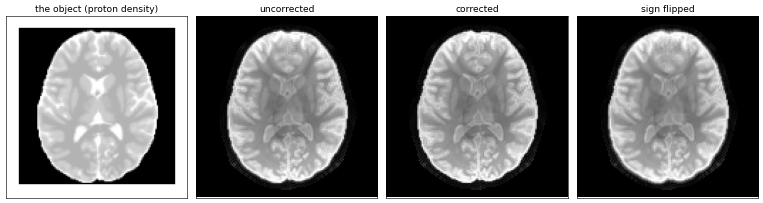

In [4]:
if BRAIN_IMAGES:
    began = time.perf_counter()
    ro = readout_of('spiral_4shot')
    data = as_shots(simulate('spiral_4shot', brain), ro)
    # The operator's image frame is the phantom's [x, y]; ESPIRiT's is the Cartesian [ky, kx].
    # One transpose, in one place, rather than a convention nobody can check later.
    sens_xy = np.swapaxes(sens, -1, -2)
    field_xy = np.swapaxes(field_hz, -1, -2)
    mask_xy = np.swapaxes(mask, -1, -2)
    segments = nc.segments_for(field_xy[mask_xy], ro.echo_relative_times(0))
    print(f'simulated in {time.perf_counter() - began:.1f} s; segments_for -> {segments}')

    brains = {}
    for label, b0 in (('uncorrected', 0.0), ('corrected', field_xy),
                      ('sign flipped', -field_xy)):
        began = time.perf_counter()
        brains[label] = nc.reconstruct(data, ro, sens=sens_xy, b0_hz=b0, segments=segments,
                                       iterations=60)
        print(f'  {label:14s} {time.perf_counter() - began:5.1f} s')

    # On the same grid as the three reconstructions beside it -- `onto_image_grid` from
    # section 1.  Without it this panel is the object over 192 mm against three images
    # over 220 mm, and the brain is drawn 15 % too large next to them.
    truth = onto_image_grid(ph.same_frame(
        ph.volume(matrix=MATRIX).PD.numpy()[..., ph.slices_of(NZ, Z_CENTER)].sum(axis=-1)))
    fig, axes = plt.subplots(1, 4, figsize=(14.0, 3.6))
    axes[0].imshow(truth, origin='lower', cmap='gray')
    axes[0].set(title='the object (proton density)', xticks=[], yticks=[])
    for ax, (label, image) in zip(axes[1:], brains.items()):
        shown = np.abs(ph.same_frame(image))
        ax.imshow(shown, origin='lower', cmap='gray', vmax=np.percentile(shown, 99.5))
        ax.set(title=label, xticks=[], yticks=[])
    fig.tight_layout()

    edge = np.abs(np.gradient(np.abs(brains['corrected'])))
    print()
    print(f'{"reconstruction":16s} {"edge energy inside the mask":>28s}')
    for label, image in brains.items():
        energy = float(np.sum(np.abs(np.gradient(np.abs(image)))[0][mask_xy] ** 2))
        print(f'{label:16s} {energy:27.1f}')
    print('  Sharper is larger.  The middle row is the point of the section and the last row is')
    print('  the failure it is measured against: the sign-flipped correction is not merely')
    print('  useless, it is worse than doing nothing, because it doubles the phase it was')
    print('  supposed to cancel.')


---
## 4. The exact operator against the segmented one

`segments=None` is the exact dense operator — `samples × pixels` complex exponentials per
application, which is the right thing to *check* a reconstruction against and useless to perform
one with. It stays because an approximation nobody checks is an assumption, and here it is checked
at 64², where both are affordable.

`segments_for` derives the count from an **accuracy target** rather than a round number of cycles,
with a floor of eight — and the constant in it is the one this table measured, which is why the
table is here rather than a paragraph.


In [5]:
import seqcraft as sc                     # noqa: E402 -- only this section needs the builder
import pypulseq as pp                     # noqa: E402

small = sc.modules.Spiral2D(
    opts=pp.Opts(max_grad=40, grad_unit='mT/m', max_slew=180, slew_unit='T/m/s', B0=3.0,
                 rf_dead_time=100e-6, rf_ringdown_time=30e-6, adc_dead_time=10e-6,
                 adc_samples_limit=8192),
    fov_mm=FOV_MM, matrix=64, shots=1, dwell_s=4e-6)
small_ro = nc.SpiralReadout(k_per_m=np.stack([small.k_per_m(shot=0)]), t_adc_s=small.t_adc_s,
                            fov_m=FOV_MM / 1e3, matrix=64, te_s=small.te_s)
step = FOV_MM / 64 / 1e3
axis = (np.arange(64) - 32) * step
gx, gy = np.meshgrid(axis, axis, indexing='ij')
small_field = 40.0 * np.exp(-((gx - 0.02) ** 2 + gy ** 2) / 0.005) - 10.0
disc = ((gx ** 2 + gy ** 2) < 0.05 ** 2).astype(np.complex64)

exact = np.asarray(nc.encoding_operator(small_ro, b0_hz=small_field, segments=None) * disc)
print(f'{np.ptp(small_ro.t_adc_s) * 1e3:.2f} ms of readout, field spanning '
      f'{np.ptp(small_field):.0f} Hz -> segments_for gives '
      f'{nc.segments_for(small_field, small_ro.echo_relative_times(0))}')
swing = float(np.ptp(small_field) * np.ptp(small_ro.t_adc_s))    # cycles across the arm
print(f'{"segments":>10s} {"relative RMSE":>15s} {"RMSE x L / swing":>20s}')
for segments in (1, 8, 16, 24, 48):
    got = np.asarray(nc.encoding_operator(small_ro, b0_hz=small_field, segments=segments) * disc)
    rmse = float(np.linalg.norm(got - exact) / np.linalg.norm(exact))
    print(f'{segments:10d} {rmse:14.2e} {rmse * segments / swing:19.2f}')
print('  The first row is no correction at all, and it is the number the rest are worth.')
print('  The last column is the constant `segments_for` inverts.  It is flat to within a')
print('  factor of two across a sixfold range of segment counts, which is what makes the')
print('  estimate an estimate rather than a guess -- and what makes its default target a')
print('  claim that can be checked rather than a number somebody liked.')
print()

# Adjointness first, because a CG on a nearly-adjoint pair does not raise: it converges to the
# wrong image and looks under-regularised.
rng = np.random.default_rng(0)
for label, segments in (('exact', None), ('segmented', 16)):
    operator = nc.encoding_operator(small_ro, b0_hz=small_field, segments=segments)
    x = (rng.standard_normal(operator.ishape)
         + 1j * rng.standard_normal(operator.ishape)).astype(np.complex64)
    y = (rng.standard_normal(operator.oshape)
         + 1j * rng.standard_normal(operator.oshape)).astype(np.complex64)
    lhs, rhs = np.vdot(y, operator * x), np.vdot(operator.H * y, x)
    print(f'  {label:10s} <Ax, y> against <x, A^H y>: {abs(lhs - rhs) / abs(lhs):.2e} relative')
print('  Composed from sigpy primitives, so the adjoint is derived rather than written -- which')
print('  is the whole reason it is composed.')


18.56 ms of readout, field spanning 40 Hz -> segments_for gives 10
  segments   relative RMSE     RMSE x L / swing
         1       1.09e+00                1.47
         8       1.33e-01                1.43
        16       5.94e-02                1.29
        24       3.58e-02                1.16


        48       1.41e-02                0.92
  The first row is no correction at all, and it is the number the rest are worth.
  The last column is the constant `segments_for` inverts.  It is flat to within a
  factor of two across a sixfold range of segment counts, which is what makes the
  estimate an estimate rather than a guess -- and what makes its default target a
  claim that can be checked rather than a number somebody liked.



  exact      <Ax, y> against <x, A^H y>: 2.28e-06 relative
  segmented  <Ax, y> against <x, A^H y>: 4.61e-07 relative
  Composed from sigpy primitives, so the adjoint is derived rather than written -- which
  is the whole reason it is composed.


---
## 5. Four interleaves together, and four separately

Four interleaves of one image are **one inverse problem**. Solving them separately and averaging
throws away exactly the joint conditioning that makes multi-shot work: no single interleaf samples
k-space at Nyquist, so each separate solve is a four-times-undersampled problem that the
regularisation has to rescue, and averaging four rescued images does not recover what the joint
solve had.


averaged against joint, inside the mask: 5.6% of the mean signal
  Averaging is not wrong -- it is a different, worse estimator, and the difference is
  structured rather than noise-like: it lives where the single-interleaf aliasing is.


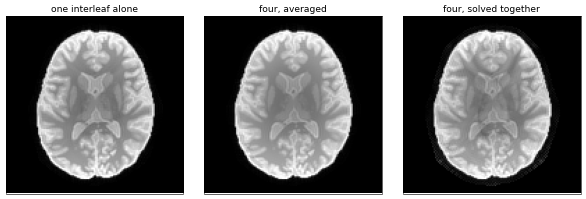

In [6]:
if BRAIN_IMAGES:
    ro = readout_of('spiral_4shot')
    joint = nc.reconstruct(data, ro, sens=sens_xy, b0_hz=field_xy, segments=segments,
                           iterations=60)
    separate = []
    for shot in range(ro.shots):
        one = nc.SpiralReadout(k_per_m=ro.k_per_m[shot:shot + 1], t_adc_s=ro.t_adc_s,
                               fov_m=ro.fov_m, matrix=ro.matrix, te_s=ro.te_s)
        separate.append(nc.reconstruct(data[:, shot:shot + 1], one, sens=sens_xy, b0_hz=field_xy,
                                       segments=segments, iterations=60))
    averaged = np.mean(separate, axis=0)

    fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.6))
    for ax, (title, image) in zip(axes, (('one interleaf alone', separate[0]),
                                         ('four, averaged', averaged),
                                         ('four, solved together', joint))):
        shown = np.abs(ph.same_frame(image))
        ax.imshow(shown, origin='lower', cmap='gray', vmax=np.percentile(shown, 99.5))
        ax.set(title=title, xticks=[], yticks=[])
    fig.tight_layout()

    scale = np.vdot(averaged[mask_xy], joint[mask_xy]) / np.vdot(averaged[mask_xy],
                                                                averaged[mask_xy])
    residual = np.abs(joint - scale * averaged)
    print(f'averaged against joint, inside the mask: '
          f'{residual[mask_xy].mean() / np.abs(joint[mask_xy]).mean():.1%} of the mean signal')
    print('  Averaging is not wrong -- it is a different, worse estimator, and the difference is')
    print('  structured rather than noise-like: it lives where the single-interleaf aliasing is.')


---
## 6. The variable-density file

`density=(1.0, 0.5)` halves the supported field of view at the edge of k-space: `R = 2` out there,
70 % of the readout, and **the same `kmax`** — so the resolution does not move and only how well
the approach to `kmax` was sampled does.

The outermost turns are genuinely aliasing. What makes it work is that they alias *high spatial
frequencies with little energy*, spread around a rotating trajectory rather than folded onto a
line — a diffuse swirl rather than a coherent replica.


weights                       range  correlation with analytic


pipe               3.01e-02 .. 2.17                    0.9952
analytic           1.82e-02 .. 1.85                    1.0000
speed              2.73e-02 .. 1.41                    0.9621
radial             4.62e-04 .. 1.81                    0.9459
  `radial` weights by |k| and `speed` by |dk/dt|; neither knows about the taper.  The
  area one sample represents is the arc spacing times the *radial turn spacing*, and
  the turn spacing is exactly what `density` changed -- which is `analytic`.  `pipe`
  needs no analytic density at all and is what a real pipeline uses.



  The third panel is the same data under `weighting="data"`, which folds sqrt(w) into
  both the operator and the data.  That is a *weighted* least squares -- a different
  estimator, not a faster path to the same one -- and on a tapered spiral the weights
  span two orders of magnitude, so the difference is not academic.


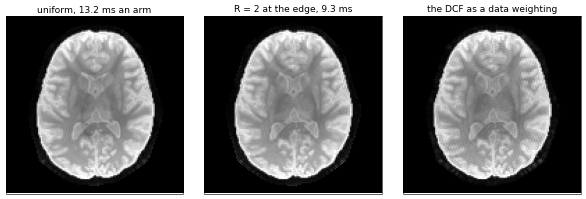

In [7]:
if BRAIN_IMAGES:
    ro_vds = readout_of('spiral_4shot_vds')
    density = nominal['spiral_4shot_vds_fov_mm_of_kr']
    data_vds = as_shots(simulate('spiral_4shot_vds', brain), ro_vds)
    vds_image = nc.reconstruct(data_vds, ro_vds, sens=sens_xy, b0_hz=field_xy,
                               segments=segments, iterations=60)

    print(f'{"weights":12s} {"range":>22s} {"correlation with analytic":>26s}')
    weights = {m: nc.dcf(ro_vds, method=m, fov_mm_of_kr=density)
               for m in ('pipe', 'analytic', 'speed', 'radial')}
    for method, w in weights.items():
        correlation = np.corrcoef(w.ravel(), weights['analytic'].ravel())[0, 1]
        print(f'{method:12s} {f"{w.min():.2e} .. {w.max():.2f}":>22s} {correlation:25.4f}')
    print('  `radial` weights by |k| and `speed` by |dk/dt|; neither knows about the taper.  The')
    print('  area one sample represents is the arc spacing times the *radial turn spacing*, and')
    print('  the turn spacing is exactly what `density` changed -- which is `analytic`.  `pipe`')
    print('  needs no analytic density at all and is what a real pipeline uses.')

    weighted = nc.reconstruct(data_vds, ro_vds, sens=sens_xy, b0_hz=field_xy, segments=segments,
                              iterations=60, weighting='data')
    fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.6))
    for ax, (title, image) in zip(axes, (
            ('uniform, 13.2 ms an arm', joint),
            ('R = 2 at the edge, 9.3 ms', vds_image),
            ("the DCF as a data weighting", weighted))):
        shown = np.abs(ph.same_frame(image))
        ax.imshow(shown, origin='lower', cmap='gray', vmax=np.percentile(shown, 99.5))
        ax.set(title=title, xticks=[], yticks=[])
    fig.tight_layout()
    print()
    print('  The third panel is the same data under `weighting="data"`, which folds sqrt(w) into')
    print('  both the operator and the data.  That is a *weighted* least squares -- a different')
    print('  estimator, not a faster path to the same one -- and on a tapered spiral the weights')
    print('  span two orders of magnitude, so the difference is not academic.')


---
## 7. T2\*, from one excitation

`echoes=3` on a spiral-out is three images from one excitation, 13.6 ms apart, with a fly-back
between them. `te_s` carries all three from the block start and `01` wrote them into the sidecar —
which is the number this section fits against, and a wrong one is a scaled T2\* map with nothing
to look wrong.


  echo 0 at TE  20.00 ms reconstructed


  echo 1 at TE  33.62 ms reconstructed


  echo 2 at TE  47.24 ms reconstructed

fitted T2* inside the mask: median 70.3 ms, 48 .. 125 ms at the deciles
  Three points 13.6 ms apart, so the fit is well conditioned for T2* near
  that spacing and increasingly not for values far above it.  The phantom carries a
  T2' map of its own; this is T2* = 1/(1/T2 + 1/T2'), which is what a gradient echo
  measures and what the fly-back between the three echoes exists to make comparable.


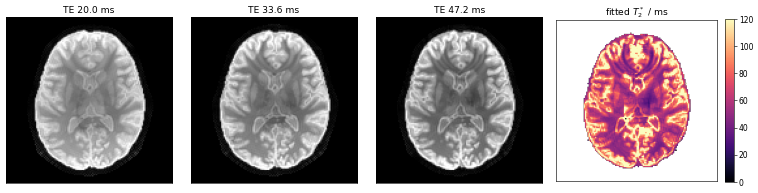

In [8]:
if BRAIN_IMAGES:
    echo_times = np.atleast_1d(nominal['spiral_4shot_me3_te_from_excitation_s'])
    signal_me3 = simulate('spiral_4shot_me3', brain)
    echo_images = []
    for echo in range(len(echo_times)):
        ro_e = readout_of('spiral_4shot_me3', echo=echo)
        per_echo = ro_e.k_per_m.shape[2]
        stacked = signal_me3.reshape(ro_e.shots, len(echo_times) * per_echo, -1)
        window = stacked[:, echo * per_echo:(echo + 1) * per_echo]
        echo_images.append(nc.reconstruct(np.moveaxis(window, -1, 0), ro_e, sens=sens_xy,
                                          b0_hz=field_xy, segments=segments, iterations=60))
        print(f'  echo {echo} at TE {echo_times[echo] * 1e3:6.2f} ms reconstructed')

    stack = np.abs(np.stack(echo_images))
    fit = np.polyfit(echo_times, np.log(np.maximum(stack, 1e-9)).reshape(len(echo_times), -1), 1)
    t2star_ms = (-1e3 / np.where(fit[0] < -1e-9, fit[0], -np.inf)).reshape(MATRIX, MATRIX)

    fig, axes = plt.subplots(1, 4, figsize=(14.0, 3.4))
    for ax, (title, image) in zip(axes, [(f'TE {t * 1e3:.1f} ms', echo_images[e])
                                         for e, t in enumerate(echo_times)]):
        shown = np.abs(ph.same_frame(image))
        ax.imshow(shown, origin='lower', cmap='gray', vmax=np.percentile(shown, 99.5))
        ax.set(title=title, xticks=[], yticks=[])
    shown = ph.same_frame(np.where(mask_xy, t2star_ms, np.nan))
    handle = axes[3].imshow(shown, origin='lower', cmap='magma', vmin=0, vmax=120)
    axes[3].set(title='fitted $T_2^*$ / ms', xticks=[], yticks=[])
    fig.colorbar(handle, ax=axes[3], fraction=0.046)
    fig.tight_layout()

    inside = mask_xy & np.isfinite(t2star_ms)
    print(f'\nfitted T2* inside the mask: median {np.median(t2star_ms[inside]):.1f} ms, '
          f'{np.percentile(t2star_ms[inside], 10):.0f} .. '
          f'{np.percentile(t2star_ms[inside], 90):.0f} ms at the deciles')
    print(f'  Three points {np.diff(echo_times)[0] * 1e3:.1f} ms apart, so the fit is well '
          f'conditioned for T2* near')
    print('  that spacing and increasingly not for values far above it.  The phantom carries a')
    print('  T2\' map of its own; this is T2* = 1/(1/T2 + 1/T2\'), which is what a gradient echo')
    print('  measures and what the fly-back between the three echoes exists to make comparable.')


---
## 8. The gradient delay, which nothing else supplies

Every number so far came from the file or from the field map. A **gradient chain delay** comes
from neither: it displaces `k` along the arm, which on a spiral is a rotation *and* a radial shift
at once, and therefore a blur that no phase correction removes.

One parameter, so it is swept rather than reasoned about — `SpiralReadout.delayed(t)` shifts the
trajectory against the samples and the sharpest reconstruction wins.


In [9]:
if BRAIN_IMAGES:
    probe = one_spin(0.0, position_px=(10, -6))
    ro = readout_of('spiral_4shot')
    truth_data = as_shots(simulate('spiral_4shot', probe), ro)
    # Simulate the delay by reconstructing with a trajectory the acquisition did not have.
    DELAYS_S = np.array([-6e-6, -3e-6, 0.0, 3e-6, 6e-6])
    print(f'{"assumed delay":>14s} {"spread":>10s} {"peak":>10s}')
    for delay_s in DELAYS_S:
        image = nc.reconstruct(truth_data, ro.delayed(delay_s), iterations=40)
        print(f'{delay_s * 1e6:12.1f}us {sharpness(image):9.2f} {np.abs(image).max():9.3f}')
    print('  Zero is the sharpest and the brightest, which is the answer this sweep is meant to')
    print('  find -- the simulator played exactly the trajectory the sidecar carries.  On a')
    print('  scanner the minimum lands somewhere else, and where it lands is the calibration.')


 assumed delay     spread       peak


        -6.0us      1.31     9.950


        -3.0us      1.18    11.615


         0.0us      1.12    12.229


         3.0us      1.18    11.685


         6.0us      1.31    10.068
  Zero is the sharpest and the brightest, which is the answer this sweep is meant to
  find -- the simulator played exactly the trajectory the sidecar carries.  On a
  scanner the minimum lands somewhere else, and where it lands is the calibration.


---
## What this notebook established

| | |
|---|---|
| **the calibration is Cartesian** | a dual-echo GRE at the spiral's own FOV and matrix recovers the phantom's field to well under a hertz, and the wrap check is an assertion rather than a comment |
| **the blur is `df` × the arm length** | measured on one spin against a `B0 = 0` control, and four interleaves buy four times less of it |
| **the sign of the field term is checkable** | and the flipped one is worse than no correction at all — which is why it survives being tested if nobody looks |
| **the segmented operator converges to the exact one** | monotonically, and `segments_for` sits above the knee |
| **four interleaves are one inverse problem** | averaging four separate solves is a different and worse estimator, and the difference is structured |
| **`R = 2` at the edge costs 30 % of the readout** | and the residual aliasing is a diffuse swirl rather than a coherent replica, which is why variable density works at all |
| **three echoes from one excitation fit T2\*** | against the echo times the sidecar carries, which is the one number a wrong value of would be invisible |
| **the gradient delay is the calibration nothing supplies** | one parameter, swept, and the sharpest reconstruction wins |
